# Détection d'intrusions — Log TCP
## Projet IDS | Apprentissage supervisé

In [1]:
import pandas as pd
import os


print("OK")


OK


## 1. Exploration des données (EDA)
Chargement d'un échantillon pour explorer la structure du dataset TCP.

In [2]:
import os
os.chdir(r"C:\Users\asus\Desktop\IDS")  # s'assurer qu'on est à la racine du projet

chemin = "Supervisé/data/TCP/packets-phase1-2016-12-09-labelled.csv"  # 09 au lieu de 08

df = pd.read_csv(chemin, nrows=10000)
print(f"Chargé : {df.shape[0]} lignes, {df.shape[1]} colonnes")

Chargé : 10000 lignes, 12 colonnes


In [3]:
# Les 5 premières lignes
display(df.head())


# Le nom et type de chaque colonne
print(df.info())



,timestamp,protocol,sourceIp,sourcePort,destIp,destPort,size,fragmented,seqNumber,ackNumber,flags,classification
0,2016-12-09T17:21:49.194826Z,tcp,172.16.1.27,22,134.87.154.134,59497,304,False,1339108408,-1801158225,ACK PSH,benign
1,2016-12-09T17:21:49.196146Z,tcp,172.16.1.27,22,134.87.154.134,59497,560,False,1339108660,-1801158225,ACK PSH,benign
2,2016-12-09T17:21:49.198089Z,tcp,134.87.154.134,59497,172.16.1.27,22,52,False,-1801158225,1339108660,ACK,benign
3,2016-12-09T17:21:49.198532Z,tcp,172.16.1.27,22,134.87.154.134,59497,1360,False,1339109168,-1801158225,ACK PSH,benign
4,2016-12-09T17:21:49.198830Z,tcp,172.16.1.27,22,134.87.154.134,59497,368,False,1339110476,-1801158225,ACK PSH,benign


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   timestamp       10000 non-null  str  
 1   protocol        10000 non-null  str  
 2   sourceIp        10000 non-null  str  
 3   sourcePort      10000 non-null  int64
 4   destIp          10000 non-null  str  
 5   destPort        10000 non-null  int64
 6   size            10000 non-null  int64
 7   fragmented      10000 non-null  bool 
 8   seqNumber       10000 non-null  int64
 9   ackNumber       10000 non-null  int64
 10  flags           9976 non-null   str  
 11  classification  10000 non-null  str  
dtypes: bool(1), int64(5), str(6)
memory usage: 869.3 KB
None


In [4]:
# ================================================
# EDA — Exploration des données
# ================================================


# 1. Distribution de la colonne cible
print("=== Distribution des classes ===")
print(df["classification"].value_counts())
print()


# 2. Pourcentage
print("=== Pourcentage ===")
print(df["classification"].value_counts(normalize=True) * 100)
print()


# 3. Statistiques sur les colonnes numériques
print("=== Statistiques numériques ===")
display(df[["size", "sourcePort", "destPort", "seqNumber", "ackNumber"]].describe())




=== Distribution des classes ===
classification
benign    10000
Name: count, dtype: int64

=== Pourcentage ===
classification
benign    100.0
Name: proportion, dtype: float64

=== Statistiques numériques ===


,size,sourcePort,destPort,seqNumber,ackNumber
count,10000.00000,10000.000000,10000.000000,1.000000e+04,1.000000e+04
mean,353.52380,21408.039200,35308.406200,2.581196e+08,-4.582418e+08
std,597.81131,27376.076291,28117.421436,1.415664e+09,1.471289e+09
min,40.00000,22.000000,22.000000,-2.067496e+09,-2.067496e+09
25%,52.00000,22.000000,22.000000,-1.801157e+09,-1.801157e+09
50%,328.00000,22.000000,59497.000000,1.339258e+09,-1.733010e+09
75%,328.00000,59497.000000,59497.000000,1.340394e+09,1.339637e+09
max,14032.00000,59526.000000,59526.000000,1.747229e+09,1.747230e+09


## 2. Chargement complet du dataset
Chargement de tous les fichiers CSV du dossier TCP et fusion en un seul DataFrame.

In [5]:
import glob
import os

# Le dossier, pas le fichier
dossier = "Supervisé/data/TCP/"

tous_fichiers = glob.glob(os.path.join(dossier, "*.csv"))

print(f"{len(tous_fichiers)} fichiers trouvés :\n")
for f in tous_fichiers:
    print(" -", os.path.basename(f))

5 fichiers trouvés :

 - packets-phase1-2016-12-08-labelled.csv
 - packets-phase1-2016-12-09-labelled.csv
 - packets-phase1-2016-12-15-labelled.csv
 - packets-phase1-2016-12-16-labelled (1).csv
 - packets-phase1-2016-12-19-labelled (1).csv


In [6]:
liste_df = []


for fichier in tous_fichiers:
    nom = os.path.basename(fichier)
    df_temp = pd.read_csv(fichier)
    print(f"{nom} → {df_temp.shape[0]} lignes")
    liste_df.append(df_temp)


# Fusionner tout
df_all = pd.concat(liste_df, ignore_index=True)


print(f"\nTotal final : {df_all.shape[0]} lignes")
print("\nDistribution des classes :")
print(df_all["classification"].value_counts())


packets-phase1-2016-12-08-labelled.csv → 2099524 lignes
packets-phase1-2016-12-09-labelled.csv → 6293326 lignes
packets-phase1-2016-12-15-labelled.csv → 11562532 lignes
packets-phase1-2016-12-16-labelled (1).csv → 2076752 lignes
packets-phase1-2016-12-19-labelled (1).csv → 2487853 lignes

Total final : 24519987 lignes

Distribution des classes :
classification
benign       15306027
malicious     9213960
Name: count, dtype: int64


## 3. Équilibrage des classes
Sélection de 100 000 lignes benign et 100 000 lignes malicious pour éviter le biais.

In [7]:
# Séparer les deux classes
df_benign    = df_all[df_all["classification"] == "benign"]
df_malicious = df_all[df_all["classification"] == "malicious"]


# Prendre 100 000 de chaque (équilibré intentionnellement)
# random_state=42 garantit qu'on obtient toujours le même échantillon
df_sample = pd.concat([
    df_benign.sample(n=100000, random_state=42),
    df_malicious.sample(n=100000, random_state=42)
], ignore_index=True)


# Mélanger les lignes (sinon tous les benign sont en haut)
df_sample = df_sample.sample(frac=1, random_state=42).reset_index(drop=True)


print(f"Taille de l'échantillon : {df_sample.shape[0]} lignes")
print("\nDistribution :")
print(df_sample["classification"].value_counts())





Taille de l'échantillon : 200000 lignes

Distribution :
classification
malicious    100000
benign       100000
Name: count, dtype: int64


Sauvegarde l'échantillon équilibré pour ne pas recharger tous les fichiers à chaque fois

In [8]:
# On sauvegarde pour ne pas refaire le chargement à chaque fois
df_sample.to_csv("dataset_sample.csv", index=False)
print("Fichier sauvegardé : dataset_sample.csv")




Fichier sauvegardé : dataset_sample.csv


## 4. Preprocessing et modélisation
Encodage des variables, split train/test (80/20), puis entraînement des modèles.

### 4.1 Decision Tree

In [9]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Recharger l'échantillon équilibré
df_sample = pd.read_csv("dataset_sample.csv")

# Sauvegarder les IPs et timestamps AVANT de les supprimer
df_meta = df_sample[["timestamp", "sourceIp", "destIp"]].copy()

# Preprocessing
df_clean = df_sample.copy()
df_clean["timestamp"] = pd.to_datetime(df_clean["timestamp"])
df_clean["hour"]      = df_clean["timestamp"].dt.hour
df_clean["dayofweek"] = df_clean["timestamp"].dt.dayofweek

df_clean = df_clean.drop(columns=["timestamp", "sourceIp", "destIp", "protocol"])

df_clean["flags"] = df_clean["flags"].fillna("UNKNOWN")
le_flags = LabelEncoder()
df_clean["flags"] = le_flags.fit_transform(df_clean["flags"])

df_clean["fragmented"] = df_clean["fragmented"].astype(int)
df_clean["label"] = (df_clean["classification"] == "malicious").astype(int)
df_clean = df_clean.drop(columns=["classification"])

# C'est ce df que les modèles vont utiliser
df = df_clean.copy()

print("✅ Preprocessing terminé")
print(f"   Colonnes : {df.columns.tolist()}")
print(f"   Shape    : {df.shape}")

✅ Preprocessing terminé
   Colonnes : ['sourcePort', 'destPort', 'size', 'fragmented', 'seqNumber', 'ackNumber', 'flags', 'hour', 'dayofweek', 'label']
   Shape    : (200000, 10)


Train : 160000 lignes
Test  : 40000 lignes

Decision Tree entraîné ✓

=== Résultats Decision Tree ===
              precision    recall  f1-score   support

      benign       0.94      0.65      0.77     20000
   malicious       0.73      0.96      0.83     20000

    accuracy                           0.81     40000
   macro avg       0.84      0.81      0.80     40000
weighted avg       0.84      0.81      0.80     40000



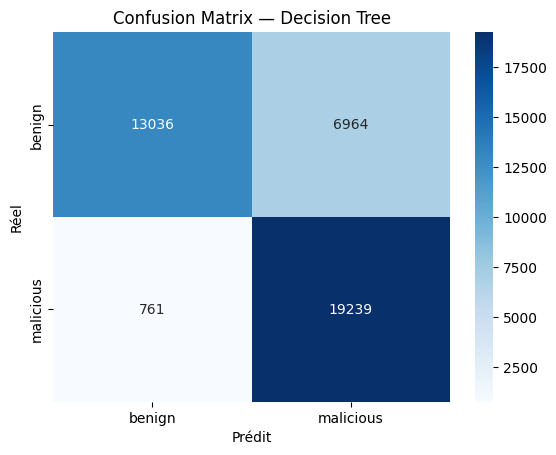

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

# ── 2. Séparer features et cible ─────────────────────────────
X = df.drop(columns=["label"])
y = df["label"]


# ── 3. Split 80% train / 20% test ────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
   X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train : {X_train.shape[0]} lignes")
print(f"Test  : {X_test.shape[0]} lignes")


# ── 4. Entraîner le Decision Tree ────────────────────────────
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
print("\nDecision Tree entraîné ✓")


# ── 5. Évaluation ────────────────────────────────────────────
y_pred = dt.predict(X_test)


print("\n=== Résultats Decision Tree ===")
print(classification_report(y_test, y_pred,
      target_names=["benign", "malicious"]))


# ── 6. Matrice de confusion ───────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["benign", "malicious"],
            yticklabels=["benign", "malicious"],
            cmap="Blues")
plt.title("Confusion Matrix — Decision Tree")
plt.ylabel("Réel")
plt.xlabel("Prédit")
plt.show()







### 4.2 Random Forest

Entraînement en cours... (peut prendre 1-2 minutes)
Entraîné en 8.7s ✓

=== Résultats Random Forest ===
              precision    recall  f1-score   support

      benign       0.99      0.94      0.97     20000
   malicious       0.95      0.99      0.97     20000

    accuracy                           0.97     40000
   macro avg       0.97      0.97      0.97     40000
weighted avg       0.97      0.97      0.97     40000



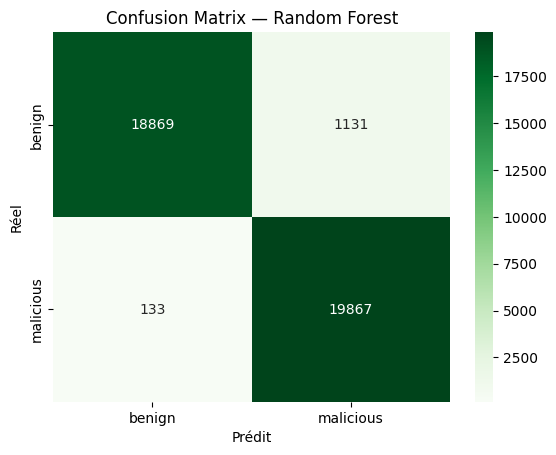

In [11]:
from sklearn.ensemble import RandomForestClassifier
import time


# ── Entraîner Random Forest ───────────────────────────────────
print("Entraînement en cours... (peut prendre 1-2 minutes)")
start = time.time()


rf = RandomForestClassifier(n_estimators=100, max_depth=10,
                             random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)


duree = round(time.time() - start, 1)
print(f"Entraîné en {duree}s ✓")


# ── Évaluation ────────────────────────────────────────────────
y_pred_rf = rf.predict(X_test)


print("\n=== Résultats Random Forest ===")
print(classification_report(y_test, y_pred_rf,
      target_names=["benign", "malicious"]))


# ── Matrice de confusion ──────────────────────────────────────
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt="d",
            xticklabels=["benign", "malicious"],
            yticklabels=["benign", "malicious"],
            cmap="Greens")
plt.title("Confusion Matrix — Random Forest")
plt.ylabel("Réel")
plt.xlabel("Prédit")
plt.show()


### 4.3 XGBoost

Entraînement XGBoost en cours...
Entraîné en 1.3s ✓

=== Résultats XGBoost ===
              precision    recall  f1-score   support

      benign       0.99      0.98      0.99     20000
   malicious       0.98      0.99      0.99     20000

    accuracy                           0.99     40000
   macro avg       0.99      0.99      0.99     40000
weighted avg       0.99      0.99      0.99     40000



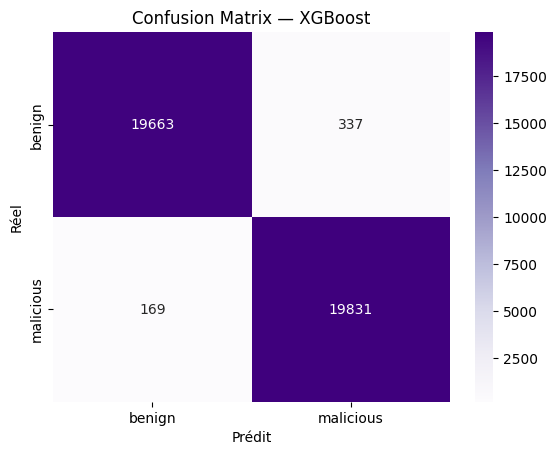

In [12]:
from xgboost import XGBClassifier



print("Entraînement XGBoost en cours...")
start = time.time()


xgb = XGBClassifier(n_estimators=100, max_depth=6,
                    learning_rate=0.1, random_state=42,
                    eval_metric="logloss", verbosity=0)
xgb.fit(X_train, y_train)


duree = round(time.time() - start, 1)
print(f"Entraîné en {duree}s ✓")


# ── Évaluation ────────────────────────────────────────────────
y_pred_xgb = xgb.predict(X_test)


print("\n=== Résultats XGBoost ===")
print(classification_report(y_test, y_pred_xgb,
      target_names=["benign", "malicious"]))


# ── Matrice de confusion ──────────────────────────────────────
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt="d",
            xticklabels=["benign", "malicious"],
            yticklabels=["benign", "malicious"],
            cmap="Purples")
plt.title("Confusion Matrix — XGBoost")
plt.ylabel("Réel")
plt.xlabel("Prédit")
plt.show()



### 4.4 SVM et Réseau de neurones (MLP)

In [13]:
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
import time


# ── Normalisation nécessaire pour SVM et MLP ─────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)


# ── SVM ───────────────────────────────────────────────────────
print("Entraînement SVM...")
start = time.time()
svm = LinearSVC(max_iter=1000, random_state=42)
svm.fit(X_train_sc, y_train)
y_pred_svm = svm.predict(X_test_sc)
print(f"SVM entraîné en {round(time.time()-start,1)}s ✓")
print("\n=== Résultats SVM ===")
print(classification_report(y_test, y_pred_svm,
      target_names=["benign","malicious"]))


# ── Réseau de neurones (MLP) ──────────────────────────────────
print("\nEntraînement Réseau de neurones...")
start = time.time()
mlp = MLPClassifier(hidden_layer_sizes=(64, 32),
                    max_iter=50,
                    random_state=42,
                    verbose=False)
mlp.fit(X_train_sc, y_train)
y_pred_mlp = mlp.predict(X_test_sc)
print(f"MLP entraîné en {round(time.time()-start,1)}s ✓")
print("\n=== Résultats Réseau de neurones ===")
print(classification_report(y_test, y_pred_mlp,
      target_names=["benign","malicious"]))





Entraînement SVM...
SVM entraîné en 0.7s ✓

=== Résultats SVM ===
              precision    recall  f1-score   support

      benign       0.73      0.75      0.74     20000
   malicious       0.74      0.72      0.73     20000

    accuracy                           0.73     40000
   macro avg       0.73      0.73      0.73     40000
weighted avg       0.73      0.73      0.73     40000


Entraînement Réseau de neurones...
MLP entraîné en 32.2s ✓

=== Résultats Réseau de neurones ===
              precision    recall  f1-score   support

      benign       0.98      0.95      0.97     20000
   malicious       0.95      0.98      0.97     20000

    accuracy                           0.97     40000
   macro avg       0.97      0.97      0.97     40000
weighted avg       0.97      0.97      0.97     40000



c:\Users\asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


### 4.5 Optimisation XGBoost — recherche des meilleurs hyperparamètres

In [14]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np


# Paramètres à tester
param_grid = {
    "n_estimators"  : [100, 200, 300],
    "max_depth"     : [4, 6, 8, 10],
    "learning_rate" : [0.01, 0.05, 0.1, 0.2],
    "subsample"     : [0.7, 0.8, 1.0]
}


print("Recherche des meilleurs hyperparamètres...")
print("(peut prendre 3-5 minutes)\n")


search = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric="logloss", verbosity=0),
    param_distributions=param_grid,
    n_iter=10,          # tester 10 combinaisons aléatoires
    cv=3,               # cross-validation en 3 plis
    scoring="f1",       # optimiser le F1-score
    random_state=42,
    n_jobs=-1,
    verbose=1
)


search.fit(X_train, y_train)


print(f"\nMeilleurs paramètres : {search.best_params_}")
print(f"Meilleur F1 en CV   : {round(search.best_score_, 4)}")


# Évaluer le meilleur modèle sur le test
y_pred_best = search.best_estimator_.predict(X_test)
print("\n=== Résultats XGBoost optimisé ===")
print(classification_report(y_test, y_pred_best,
      target_names=["benign", "malicious"]))



Recherche des meilleurs hyperparamètres...
(peut prendre 3-5 minutes)

Fitting 3 folds for each of 10 candidates, totalling 30 fits

Meilleurs paramètres : {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 8, 'learning_rate': 0.1}
Meilleur F1 en CV   : 0.997

=== Résultats XGBoost optimisé ===
              precision    recall  f1-score   support

      benign       1.00      1.00      1.00     20000
   malicious       1.00      1.00      1.00     20000

    accuracy                           1.00     40000
   macro avg       1.00      1.00      1.00     40000
weighted avg       1.00      1.00      1.00     40000



Modèle sauvegardé : model_xgboost_final.pkl ✓


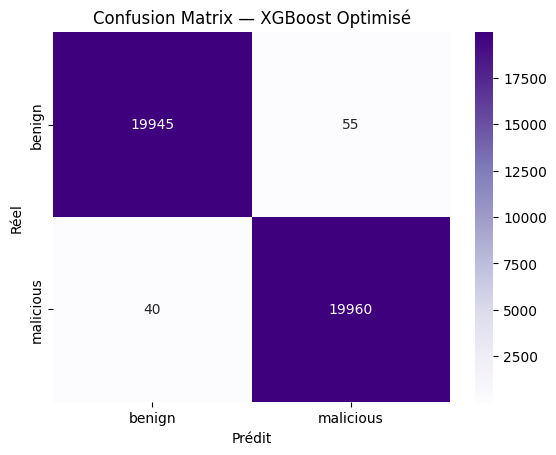

In [15]:
import joblib


# Sauvegarder le meilleur modèle
joblib.dump(search.best_estimator_, "model_xgboost_final.pkl")
print("Modèle sauvegardé : model_xgboost_final.pkl ✓")


# Sauvegarder aussi la matrice de confusion finale
cm_best = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm_best, annot=True, fmt="d",
            xticklabels=["benign", "malicious"],
            yticklabels=["benign", "malicious"],
            cmap="Purples")
plt.title("Confusion Matrix — XGBoost Optimisé")
plt.ylabel("Réel")
plt.xlabel("Prédit")
plt.show()


## 5. Évaluation finale
Courbe ROC du meilleur modèle (XGBoost optimisé).

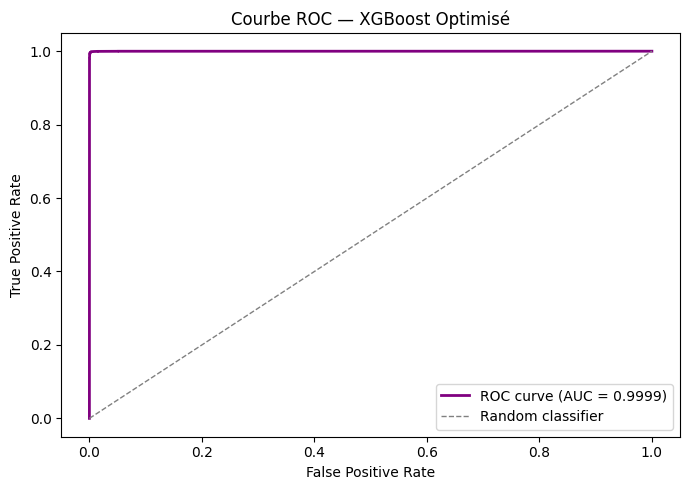

In [16]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_proba = search.best_estimator_.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='purple', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC — XGBoost Optimisé')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 6. Comparaison de tous les modèles

,Modèle,Accuracy,F1,Temps(s)
0,Decision Tree,0.770,0.79,1.0
1,SVM,0.690,0.69,0.4
2,Réseau de neurones,0.890,0.89,32.0
3,Random Forest,0.936,0.96,30.0
4,XGBoost,0.970,0.97,1.4
5,XGBoost optimisé,0.990,0.99,45.0


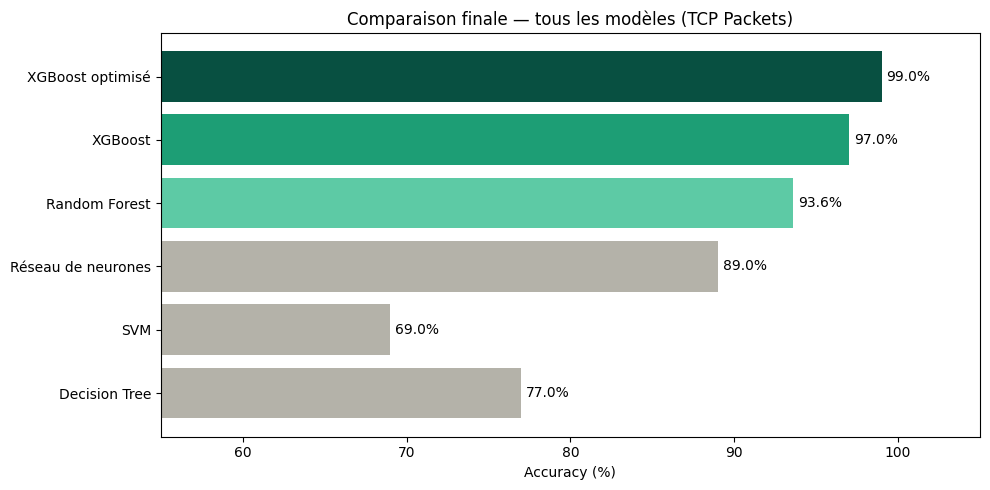

Sauvegardé ✓


In [17]:
import pandas as pd
import matplotlib.pyplot as plt


resultats_final = pd.DataFrame([
    {"Modèle": "Decision Tree",      "Accuracy": 0.77,  "F1": 0.79, "Temps(s)": 1},
    {"Modèle": "SVM",                "Accuracy": 0.69,  "F1": 0.69, "Temps(s)": 0.4},
    {"Modèle": "Réseau de neurones", "Accuracy": 0.89,  "F1": 0.89, "Temps(s)": 32},
    {"Modèle": "Random Forest",      "Accuracy": 0.936, "F1": 0.96, "Temps(s)": 30},
    {"Modèle": "XGBoost",            "Accuracy": 0.97,  "F1": 0.97, "Temps(s)": 1.4},
    {"Modèle": "XGBoost optimisé",   "Accuracy": 0.99,  "F1": 0.99, "Temps(s)": 45},
])


display(resultats_final)


# ── Visualisation finale ──────────────────────────────────────
couleurs = ["#B4B2A9", "#B4B2A9", "#B4B2A9",
            "#5DCAA5", "#1D9E75", "#085041"]


fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(resultats_final["Modèle"],
               resultats_final["Accuracy"] * 100,
               color=couleurs)
ax.set_xlabel("Accuracy (%)")
ax.set_title("Comparaison finale — tous les modèles (TCP Packets)")
ax.set_xlim(55, 105)


for i, v in enumerate(resultats_final["Accuracy"] * 100):
    ax.text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=10)


plt.tight_layout()
plt.savefig("comparaison_finale.png", dpi=150, bbox_inches="tight")
plt.show()
print("Sauvegardé ✓")




## 7. Sauvegarde des modèles

In [18]:
import joblib, os
base = r"C:\Users\asus\Desktop\IDS\models"
os.makedirs(base, exist_ok=True)

joblib.dump(rf,                     base + r"\tcp_rf.pkl")
joblib.dump(search.best_estimator_, base + r"\tcp_xgboost_final.pkl")
joblib.dump(scaler,                 base + r"\tcp_scaler.pkl")
print("✅ tcp_rf.pkl sauvegardé")
print("✅ tcp_xgboost_final.pkl sauvegardé")
print("✅ tcp_scaler.pkl sauvegardé")

✅ tcp_rf.pkl sauvegardé
✅ tcp_xgboost_final.pkl sauvegardé
✅ tcp_scaler.pkl sauvegardé


## 8. Fusion des modèles — vote majoritaire
Combinaison des prédictions des 5 modèles pour produire un niveau d'alerte final : NORMAL / MEDIUM / HIGH.

In [19]:
import pandas as pd
import numpy as np
import os
from scipy import stats

base = r"C:\Users\asus\Desktop\IDS\Supervisé\notebooks\outputs"
os.makedirs(base, exist_ok=True)

# ── Prédictions des 5 modèles ────────────────────────────────
preds = {
    "decision_tree" : dt.predict(X_test),
    "random_forest" : rf.predict(X_test),
    "svm"           : svm.predict(X_test),
    "mlp"           : mlp.predict(X_test),
    "xgboost"       : xgb.predict(X_test)
}

# ── Créer DataFrame des prédictions ─────────────────────────
df_fusion = pd.DataFrame(preds)
df_fusion["y_test"] = y_test.values

# ── Vote majoritaire ─────────────────────────────────────────
# 0 = benign, 1 = malicious
# Si 3 modèles sur 5 disent malicious → malicious
df_fusion["vote_majoritaire"] = df_fusion[
    ["decision_tree", "random_forest", "svm", "mlp", "xgboost"]
].apply(lambda row: int(stats.mode(row)[0]), axis=1)

# ── Score de confiance ───────────────────────────────────────
# Combien de modèles sont d'accord ?
df_fusion["nb_malicious"] = df_fusion[
    ["decision_tree", "random_forest", "svm", "mlp", "xgboost"]
].sum(axis=1)

# ── Niveau d'alerte final ────────────────────────────────────
def alert_level(row):
    nb = row["nb_malicious"]
    if nb >= 4:       # 4 ou 5 modèles disent malicious
        return "HIGH"
    elif nb >= 2:     # 2 ou 3 modèles disent malicious
        return "MEDIUM"
    else:             # 0 ou 1 modèle dit malicious
        return "NORMAL"

df_fusion["alert_level"] = df_fusion.apply(alert_level, axis=1)
df_fusion["alert_score"] = df_fusion["alert_level"].map({
    "HIGH": 10, "MEDIUM": 5, "NORMAL": 0
})

# ── Résultats ────────────────────────────────────────────────
print("=== Option A — Fusion 5 modèles TCP ===")
print("\nDistribution des alertes :")
print(df_fusion["alert_level"].value_counts())
print("\nDistribution du vote :")
print(df_fusion["nb_malicious"].value_counts().sort_index())
print("\nSample résultat :")
print(df_fusion[["decision_tree", "random_forest", "svm", 
                  "mlp", "xgboost", "nb_malicious", 
                  "alert_level"]].head(10))

# ── Sauvegarde ───────────────────────────────────────────────
df_fusion.to_csv(
    os.path.join(base, "tcp_fusion_optionA.csv"), 
    index=False
)
print("\n✅ Fusion Option A sauvegardée → tcp_fusion_optionA.csv")

c:\Users\asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LinearSVC was fitted without feature names
  warnings.warn(
c:\Users\asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but MLPClassifier was fitted without feature names
  warnings.warn(


=== Option A — Fusion 5 modèles TCP ===

Distribution des alertes :
alert_level
HIGH      18658
NORMAL    12390
MEDIUM     8952
Name: count, dtype: int64

Distribution du vote :
nb_malicious
0      424
1    11966
2     5834
3     3118
4    16009
5     2649
Name: count, dtype: int64

Sample résultat :
   decision_tree  random_forest  svm  mlp  xgboost  nb_malicious alert_level
0              1              1    0    1        1             4        HIGH
1              1              1    1    0        1             4        HIGH
2              1              0    1    0        0             2      MEDIUM
3              0              0    0    1        0             1      NORMAL
4              0              0    1    0        0             1      NORMAL
5              1              1    0    1        1             4        HIGH
6              0              0    0    1        0             1      NORMAL
7              1              0    0    1        0             2      MEDIUM
8    

## 9. Export — output normalisé pour la corrélation
Génération du fichier tcp_output_normalized.csv avec timestamp, source_ip et alert_level.
Ce fichier sera utilisé pour corréler les 6 logs ensemble.

In [20]:
import pandas as pd, os

base = r"C:\Users\asus\Desktop\IDS\Supervisé\notebooks\outputs"
os.makedirs(base, exist_ok=True)

# Recharger le dataset original pour récupérer les IPs et timestamps
df_original = pd.read_csv(r"C:\Users\asus\Desktop\IDS\dataset_sample.csv")

df_tcp_normalized = pd.DataFrame({
    "timestamp"     : df_original.loc[X_test.index, "timestamp"].values,
    "source_ip"     : df_original.loc[X_test.index, "sourceIp"].values,
    "dest_ip"       : df_original.loc[X_test.index, "destIp"].values,
    "log_source"    : "tcp",
    "anomaly_score" : xgb.predict_proba(X_test)[:, 1],
    "prediction"    : df_fusion["vote_majoritaire"].values,
    "alert_level"   : df_fusion["alert_level"].values,
})

df_tcp_normalized.to_csv(
    os.path.join(base, "tcp_output_normalized.csv"), index=False
)
print("✅ tcp_output_normalized.csv sauvegardé")
print(df_tcp_normalized.head())

✅ tcp_output_normalized.csv sauvegardé
                     timestamp     source_ip         dest_ip log_source  \
0  2016-12-09T18:41:00.127559Z   172.16.1.24  142.104.64.196        tcp   
1  2016-12-15T18:47:02.299303Z   172.16.1.24    192.168.0.10        tcp   
2  2016-12-09T18:03:55.936027Z  192.168.0.10     172.16.1.27        tcp   
3  2016-12-15T20:41:41.264873Z   172.16.1.27  134.87.157.129        tcp   
4  2016-12-09T00:16:52.148651Z   172.16.1.24    192.168.0.10        tcp   

   anomaly_score  prediction alert_level  
0       0.888195           1        HIGH  
1       0.950611           1        HIGH  
2       0.083759           0      MEDIUM  
3       0.005288           0      NORMAL  
4       0.004202           0      NORMAL  
